In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("/content/train.csv" , usecols = ['Age','Fare','Survived'])

In [ ]:
df.dropna(inplace = True) #removing all the columns which have empty values

In [ ]:
df.shape

(714, 3)

In [ ]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 42)

In [ ]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6303012519561815)

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=10, encode = 'ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins = 10 , encode = 'ordinal' , strategy='quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.named_transformers_['first'].n_bins_

array([10])

In [ ]:
trf.named_transformers_['second'].n_bins_

array([10])

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [ ]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins = trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                               bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
616,34.0,6.0,14.4000,4.0,"(32.0, 36.0]","(13.0, 15.75]"
355,28.0,4.0,9.5000,3.0,"(25.0, 28.5]","(9.225, 13.0]"
486,35.0,6.0,90.0000,9.0,"(32.0, 36.0]","(82.171, 512.329]"
797,31.0,5.0,8.6833,2.0,"(28.5, 32.0]","(7.896, 9.225]"
314,43.0,8.0,26.2500,6.0,"(42.0, 50.0]","(26.0, 29.125]"


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf , y_train)
y_pred2 = clf.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [ ]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier() , x , y ,cv = 10 , scoring='accuracy'))

np.float64(0.6303012519561815)

In [ ]:
def discretize(bins , strategy):
  kbin_age = KBinsDiscretizer(n_bins = bins, encode = 'ordinal' , strategy = strategy)
  kbin_fare = KBinsDiscretizer(n_bins = bins , encode = 'ordinal' , strategy = strategy)
  trf = ColumnTransformer([
      ('first' , kbin_age,[0]),
      ('second' , kbin_fare , [1])
  ])
  x_trf = trf.fit_transform(x)
  print(np.mean(cross_val_score(DecisionTreeClassifier() ,x , y , cv = 10 , scoring='accuracy')))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(x['Age'])
  plt.title('Before')

  plt.subplot(122)
  plt.hist(X_trf[:,0],color = 'red')
  plt.title('after')

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(x['Fare'])
  plt.title('Before')

  plt.subplot(122)
  plt.hist(X_trf[:,1],color = 'red')
  plt.title('after')

  plt.show()

0.6345070422535211


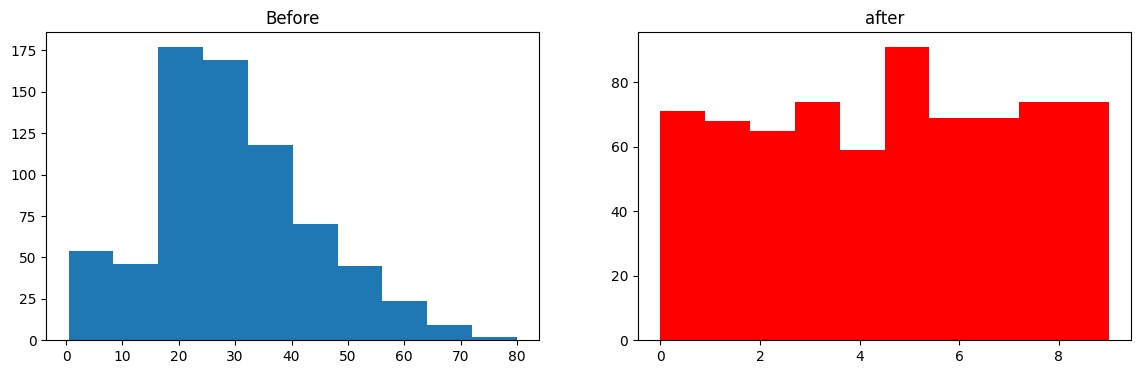

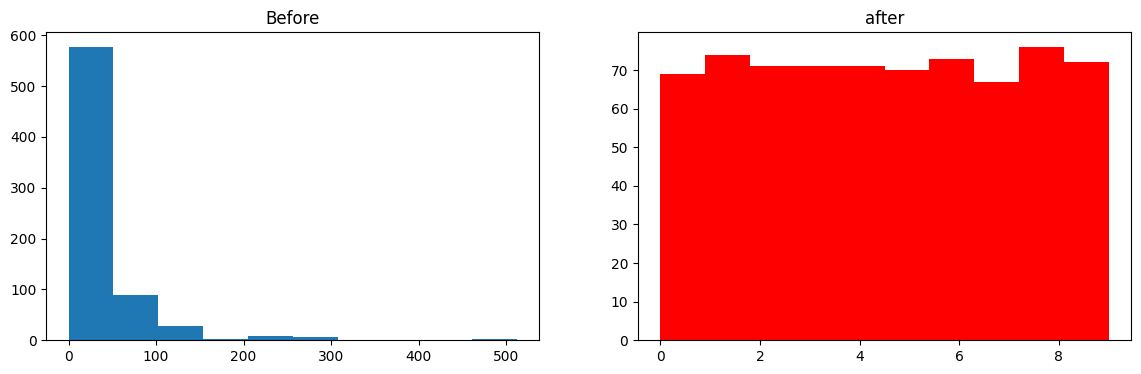

In [ ]:
discretize(15 , 'quantile')

0.6317683881064162


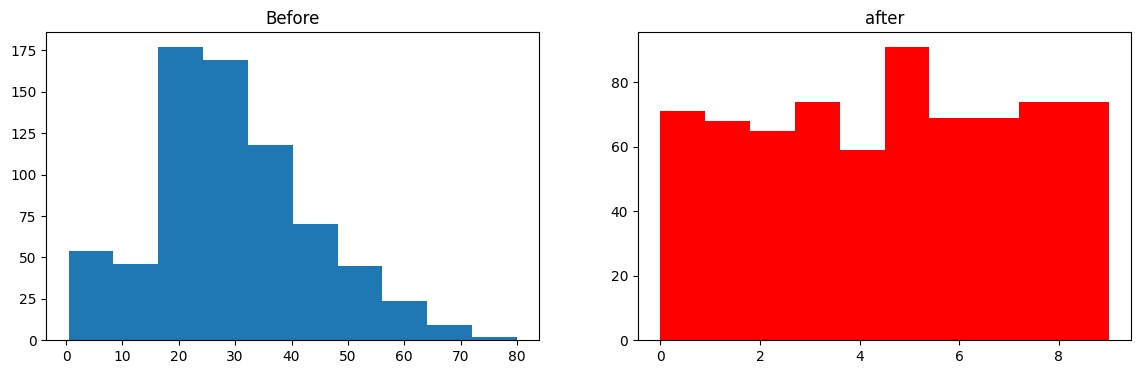

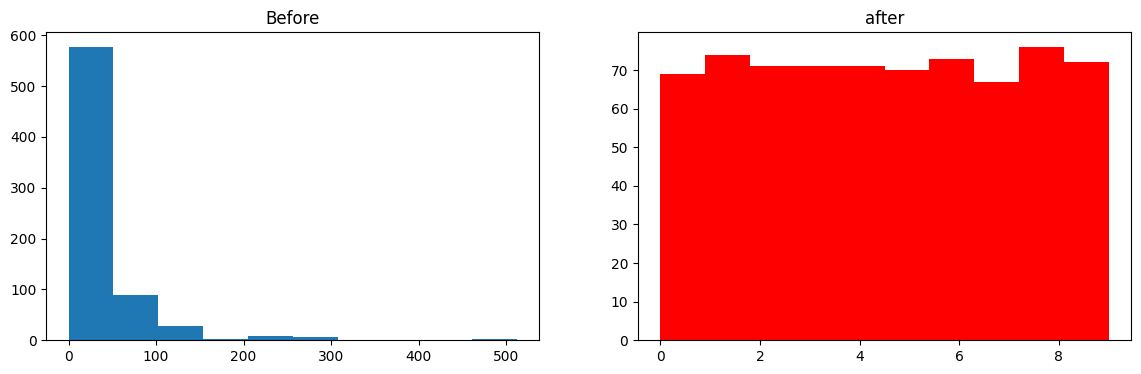

In [ ]:
discretize(15 , 'uniform')